In [1]:
from google.colab import files

uploaded = files.upload()


Saving Online Retail Data Set.xlsx to Online Retail Data Set.xlsx


In [6]:
import pandas as pd

df = pd.read_excel('Online Retail Data Set.xlsx')

# Clean
df = df[df['Quantity'] >= 1]
df = df[df['UnitPrice'] > 0]

# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Q1 - monthly revenue 2011
df_2011 = df.copy()
df_2011['InvoiceDate'] = pd.to_datetime(df_2011['InvoiceDate'])
df_2011 = df_2011[df_2011['InvoiceDate'].dt.year == 2011]
df_2011['Month'] = df_2011['InvoiceDate'].dt.month
monthly_revenue = df_2011.groupby('Month')['Revenue'].sum()

print(monthly_revenue)

Month
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      759138.380
9     1058590.172
10    1154979.300
11    1509496.330
12     638792.680
Name: Revenue, dtype: float64


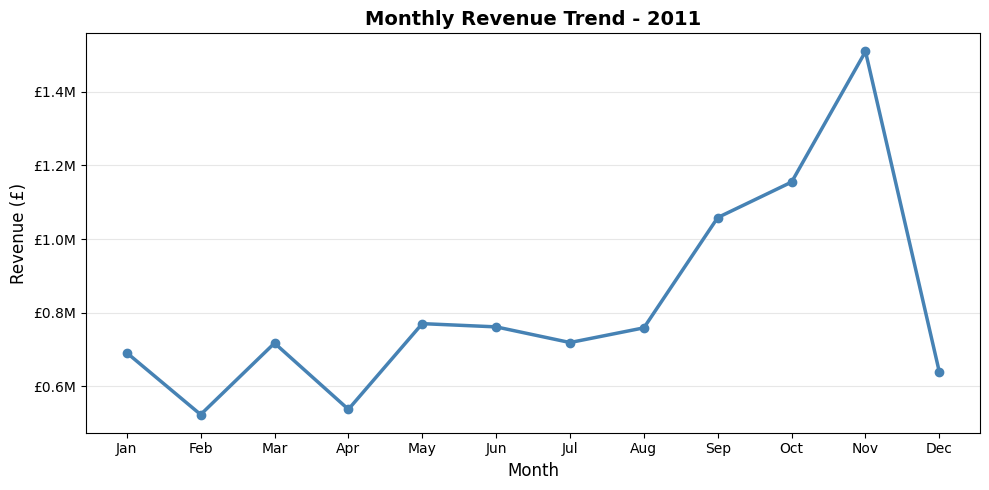

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Q1 - Line chart
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(monthly_revenue.index,
        monthly_revenue.values,
        color='steelblue',
        marker='o',
        linewidth=2.5)
ax.set_title('Monthly Revenue Trend - 2011',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May',
                    'Jun','Jul','Aug','Sep',
                    'Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'£{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('q1_monthly_revenue.png', dpi=150)
plt.show()

In [8]:
df_no_uk = df[df['Country'] != 'United Kingdom']
top_revenue = df_no_uk.groupby('Country')[['Revenue', 'Quantity']].sum()
top_10 = top_revenue.nlargest(10,'Revenue')

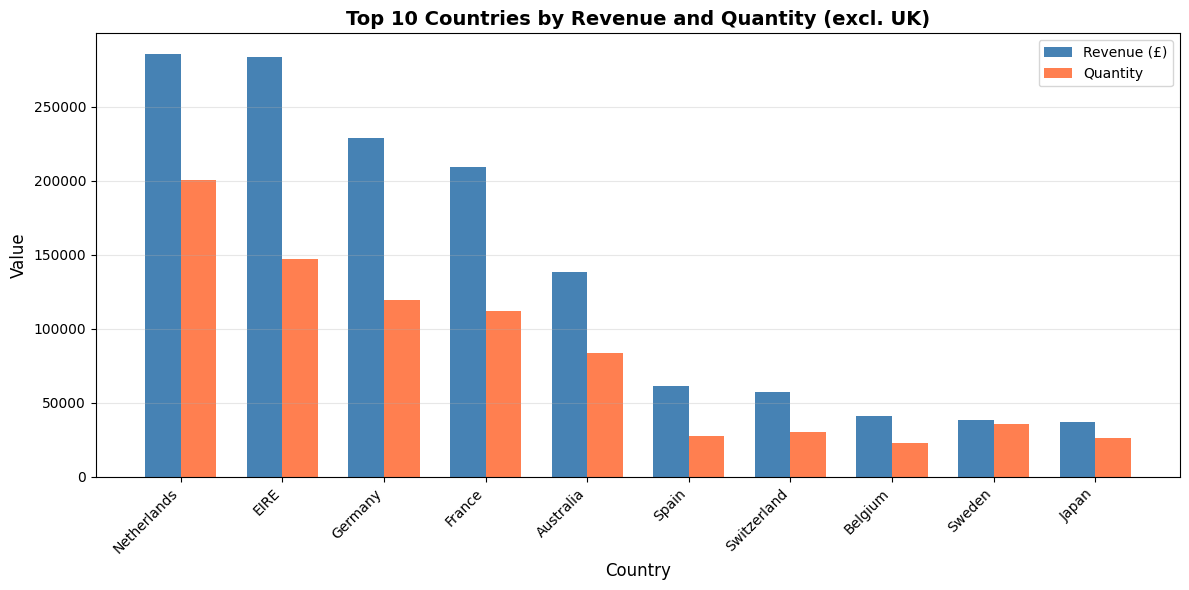

In [9]:
fig, ax = plt.subplots(figsize=(12,6))

x = range(len(top_10.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               top_10['Revenue'],
               width,
               label='Revenue (£)',
               color='steelblue')

bars2 = ax.bar([i + width/2 for i in x],
               top_10['Quantity'],
               width,
               label='Quantity',
               color='coral')

ax.set_title('Top 10 Countries by Revenue and Quantity (excl. UK)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(top_10.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('q2_top_countries.png', dpi=150)
plt.show()

In [10]:
df_no_uk = df[df['Country'] != 'United Kingdom']
top_revenue = df_no_uk.groupby('Country')[['Revenue', 'Quantity']].sum()
top_10 = top_revenue.nlargest(10,'Revenue')

print(top_10)


               Revenue  Quantity
Country                         
Netherlands  285446.34    200361
EIRE         283453.96    147173
Germany      228867.14    119261
France       209715.11    112103
Australia    138521.31     83901
Spain         61577.11     27940
Switzerland   57089.90     30629
Belgium       41196.34     23237
Sweden        38378.33     36083
Japan         37416.37     26016


In [11]:
# Define top_10_customers before its usage in the subsequent plotting cell (lBkPTmrPDU_m).
# This code is derived from g8WNCD55G_w7.
df_customers = df.dropna(subset=['CustomerID'])
top_customers = df_customers.groupby('CustomerID')['Revenue'].sum()
top_10_customers = top_customers.nlargest(10)

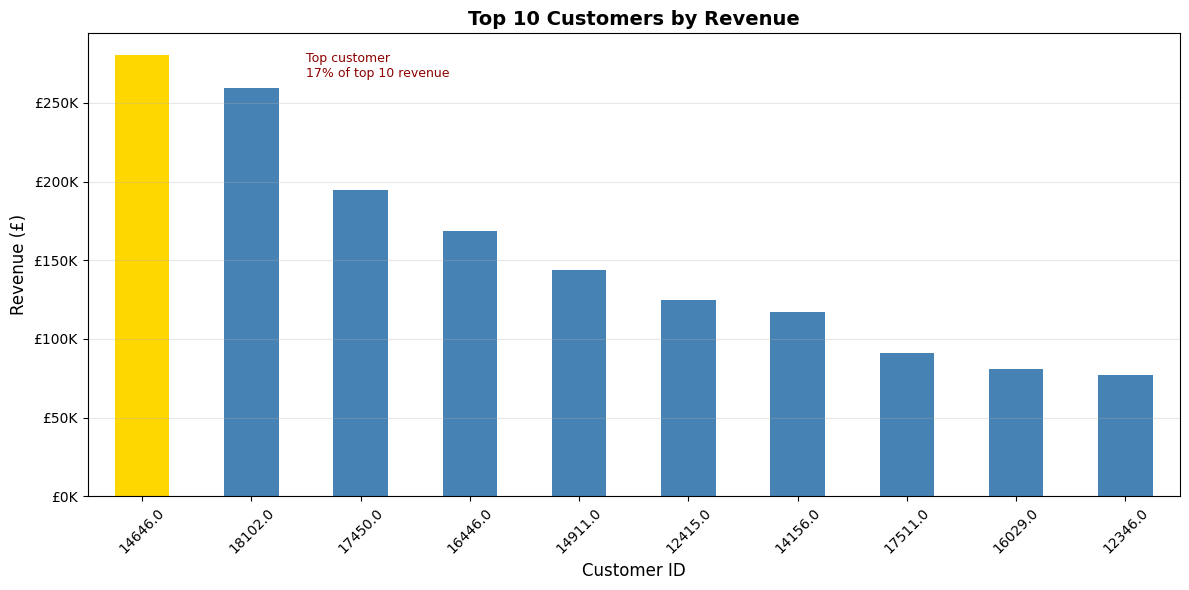

In [12]:
fig, ax = plt.subplots(figsize=(12,6))

colors = ['gold' if i == 0 else 'steelblue'
          for i in range(len(top_10_customers))]

top_10_customers.sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=colors)

ax.set_title('Top 10 Customers by Revenue',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Customer ID', fontsize=12)
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'£{x/1e3:.0f}K'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

ax.annotate('Top customer\n17% of top 10 revenue',
            xy=(0, top_10_customers.max()),
            xytext=(1.5, top_10_customers.max()*0.95),
            fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig('q3_top_customers.png', dpi=150)
plt.show()

In [15]:
import pandas as pd

df = pd.read_excel('Online Retail Data Set.xlsx')

# Clean
df = df[df['Quantity'] >= 1]
df = df[df['UnitPrice'] > 0]

# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [16]:
df=df.dropna(subset=['CustomerID'])
top_customers = df.groupby('CustomerID')['Revenue'].sum()
top_10_customers = top_customers.nlargest(10)
print(top_10_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


In [17]:
df_no_uk = df[df['Country'] != 'United Kingdom']
country_quantity = df_no_uk.groupby('Country')['Quantity'].sum()

In [19]:
import pandas as pd

df = pd.read_excel('Online Retail Data Set.xlsx')

# Clean
df = df[df['Quantity'] >= 1]
df = df[df['UnitPrice'] > 0]

# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Define top_10_customers, derived from g8WNCD55G_w7
df_cleaned_customers = df.dropna(subset=['CustomerID'])
top_customers = df_cleaned_customers.groupby('CustomerID')['Revenue'].sum()
top_10_customers = top_customers.nlargest(10)

In [20]:
# Define country_quantity before its usage in the subsequent plotting cell (FwJnZN95HMO4).
# This code is derived from ULI2gPMVJpj8.
df_no_uk = df[df['Country'] != 'United Kingdom']
country_quantity = df_no_uk.groupby('Country')['Quantity'].sum()

In [21]:
df_cleaned_customers = df.dropna(subset=['CustomerID'])

top_customers = df_cleaned_customers.groupby('CustomerID')['Revenue'].sum()
top_10_customers = top_customers.nlargest(10)

total_revenue = df_cleaned_customers['Revenue'].sum()
top_10_customers_revenue = top_10_customers.sum()

percentage_contribution = (top_10_customers_revenue / total_revenue) * 100

print(f"The top 10 customers contribute {percentage_contribution:.2f}% of the total revenue.")

The top 10 customers contribute 17.26% of the total revenue.


In [22]:
df_no_uk = df[df['Country'] != 'United Kingdom']
country_quantity = df_no_uk.groupby('Country')['Quantity'].sum()
print('country_quantity')

country_quantity


In [23]:
import plotly.express as px

df_no_uk = df[df['Country'] != 'United Kingdom']
country_quantity = df_no_uk.groupby('Country')['Quantity'].sum()

fig = px.choropleth(
    country_quantity.reset_index(),
    locations='Country',
    locationmode='country names',
    color='Quantity',
    title='Demand by Country'
)
import plotly.io as pio
pio.write_html(fig, 'q4_map.html')
fig.show()

In [24]:
df.to_excel('Online Retail Data Set.xlsx', index=False)